# 30 - L1 Regularization (Lasso)

**Section:** Regularization | **Prereqs:** `Regularization/Weight_Regularization_(L2).ipynb` | **Next:** `Metaparameters/ExploringWineDataSet.ipynb`

Same idea as L2, different norm - and a genuinely different effect:

    total_loss = data_loss + lambda * sum(|w|)

**Why L1 gives sparsity.** The gradient of `|w|` is `sign(w)`, a constant push of
the same size no matter how small `w` gets. So a weight that is not useful is
pushed all the way to *exactly* zero and stays there. L2's gradient is `2*w`,
which shrinks as the weight shrinks - it approaches zero without arriving.

| | L1 | L2 |
|---|---|---|
| Penalty | sum of \|w\| | sum of w^2 |
| Gradient | constant (sign) | proportional to w |
| Result | many weights exactly 0 | all weights small |
| Use | feature selection, model compression | general-purpose smoothing |

**PyTorch has no `l1_decay`,** so this notebook adds the term to the loss by
hand - which is also the general recipe for any custom penalty: compute a
differentiable scalar from the parameters, add it to the loss, let autograd do
the rest.

**Two runs to compare:** the penalty averaged over the weight count, and the raw
sum. Averaging makes `lambda` roughly independent of model size, so a value tuned
on a small model still means something on a big one.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader , TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

data = torch.tensor(iris.data, dtype=torch.float)
label = torch.tensor(iris.target, dtype=torch.long)

In [ ]:
data_train, data_test, label_train, label_test = train_test_split(data,label, test_size=0.25)

train_data = TensorDataset(data_train, label_train)
test_data = TensorDataset(data_test, label_test)


bs = 8
train_loader = DataLoader(train_data ,batch_size=bs ,shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [ ]:
# A plain Sequential model this time - the penalty is computed from
# model.named_parameters(), which works the same either way.
model = nn.Sequential(
    nn.Linear(4,128),
    nn.ReLU(),
    nn.Linear(128,128),
    nn.ReLU(),
    nn.Linear(128,3)

)

In [ ]:
# Named parameters: '0.weight', '0.bias', '2.weight', ... Sequential names
# layers by index.
for i in model.named_parameters():
  print(i[0],i[1].shape)
  print()

0.weight torch.Size([128, 4])

0.bias torch.Size([128])

2.weight torch.Size([128, 128])

2.bias torch.Size([128])

4.weight torch.Size([3, 128])

4.bias torch.Size([3])



In [ ]:
# .numel() gives the element count per tensor - needed to normalise the penalty.
for i in model.named_parameters():
  print(i[0],i[1].shape , i[1].numel())
  print()

0.weight torch.Size([128, 4]) 512

0.bias torch.Size([128]) 128

2.weight torch.Size([128, 128]) 16384

2.bias torch.Size([128]) 128

4.weight torch.Size([3, 128]) 384

4.bias torch.Size([3]) 3



In [ ]:
for i in model.parameters():
  print(i.shape)

torch.Size([128, 4])
torch.Size([128])
torch.Size([128, 128])
torch.Size([128])
torch.Size([3, 128])
torch.Size([3])


In [ ]:
# Count WEIGHTS only, skipping biases.
# Biases are excluded from weight penalties by convention: a bias just shifts a
# unit's threshold, it does not control how strongly inputs are combined, and
# penalising it only limits the model's ability to centre its activations.
# (Shadowing the builtin `sum` here is harmless but best avoided.)
sum = 0

for pname, w in model.named_parameters():
  if "bias" not in pname:
    sum += w.numel()

In [ ]:
print(sum)

17280


In [ ]:
# lambda = 0.01. There is no weight_decay-style shortcut for L1, so the term is
# built by hand in the loop below.
# Now we train a simple model with L1 Regurlarization (Lasso)

l1_Lambda = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr = 0.005)
lossFunc = nn.CrossEntropyLoss()

In [ ]:
# L1 by hand, inside the batch loop:
#   1. compute the ordinary data loss,
#   2. sum |w| over every weight tensor (autograd tracks this - it is a function
#      of the live parameters, so backward() reaches them),
#   3. add lambda * (that sum / num_weights) to the loss.
#
# The division by num_weights makes lambda comparable across model sizes; the
# second run below drops it to show the difference.
# The penalty must be recomputed every step, because the weights change every
# step. Note losses[i] therefore records data loss + penalty, so it is not
# directly comparable to an unregularised run's loss.
epochs = 10000
losses = torch.zeros(epochs)
test_acc = []
train_acc = []

num_weights = 0

for name,elems in model.named_parameters():
  if "bias" not in name:
   num_weights += elems.numel()



for i in range(epochs):

  model.train()
  batch_accuracy = []

  for x,y in train_loader:

    yhat = model(x)

    loss = lossFunc(yhat,y)

    L1_term = torch.tensor(0.,requires_grad=True)

    for name,elems in model.named_parameters():
      if "bias" not in name:
       L1_term  = L1_term + torch.sum(torch.abs(elems))

    loss = loss + l1_Lambda * (L1_term/num_weights) ## Whe can just use the L1_term too. We divide it by no of weights to make it independent of the num of weights.
    losses[i] = loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_accuracy.append(100*torch.mean((torch.argmax(yhat,dim=1) == y).float()) )


  train_acc.append(torch.mean(torch.tensor(batch_accuracy)))

  model.eval()
  with torch.no_grad():
   X,Y = next(iter(test_loader))
   test_acc.append(100*torch.mean((torch.argmax(model(X),dim=1) == Y).float()) )

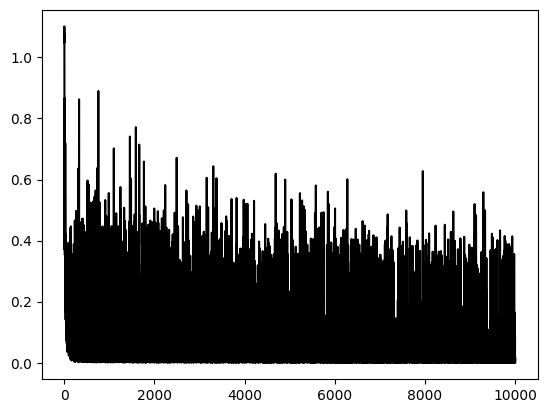

In [ ]:
# Total loss (data + penalty). It plateaus above zero - the penalty term never
# vanishes while any weight is non-zero.
plt.plot(losses.detach(), "k-");

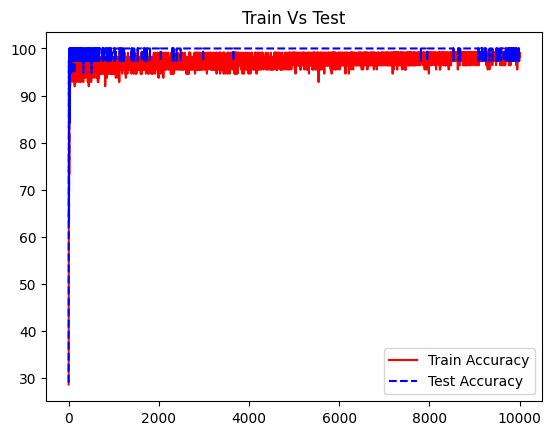

In [ ]:
# Train vs test accuracy. Look for the gap being narrower than an
# unregularised run's.
plt.plot(train_acc ,"r", label="Train Accuracy")
plt.plot(test_acc, "b--", label="Test Accuracy")
plt.title("Train Vs Test")
plt.legend();

### Now we train the model with just the sums and the L1_term (penelty)

In [ ]:
# The same experiment with the RAW SUM instead of the average, and lambda scaled
# down 10x to compensate.
# The lesson: lambda's meaning depends on how the penalty is normalised. Averaged
# penalties transfer between models; raw sums have to be re-tuned whenever the
# parameter count changes.
model = nn.Sequential(
    nn.Linear(4,128),
    nn.ReLU(),
    nn.Linear(128,128),
    nn.ReLU(),
    nn.Linear(128,3)

)

# Now we train a simple model with L1 Regurlarization with just the sums, not the average

l1_Lambda = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr = 0.005)
lossFunc = nn.CrossEntropyLoss()

epochs = 10000
losses = torch.zeros(epochs)
test_acc = []
train_acc = []

num_weights = 0

for name,elems in model.named_parameters():
  if "bias" not in name:
   num_weights += elems.numel()



for i in range(epochs):

  model.train()
  batch_accuracy = []

  for x,y in train_loader:

    yhat = model(x)

    loss = lossFunc(yhat,y)

    L1_term = torch.tensor(0.,requires_grad=True)

    for name,elems in model.named_parameters():
      if "bias" not in name:
       L1_term  = L1_term + torch.sum(torch.abs(elems))

    loss = loss + (l1_Lambda * L1_term) #Using just the sums
    losses[i] = loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_accuracy.append(100*torch.mean((torch.argmax(yhat,dim=1) == y).float()) )


  train_acc.append(torch.mean(torch.tensor(batch_accuracy)))

  model.eval()
  with torch.no_grad():
   X,Y = next(iter(test_loader))
   test_acc.append(100*torch.mean((torch.argmax(model(X),dim=1) == Y).float()) )


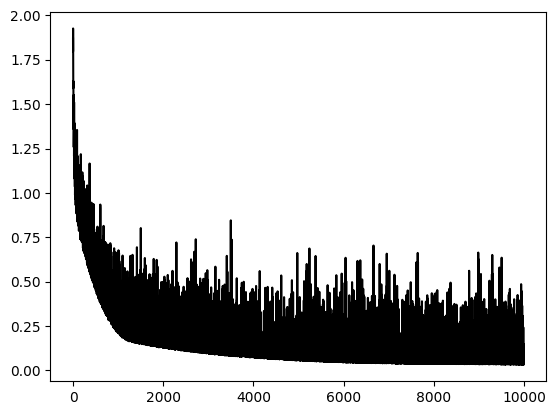

In [ ]:
# Loss for the raw-sum version.
plt.plot(losses.detach(), "k-");

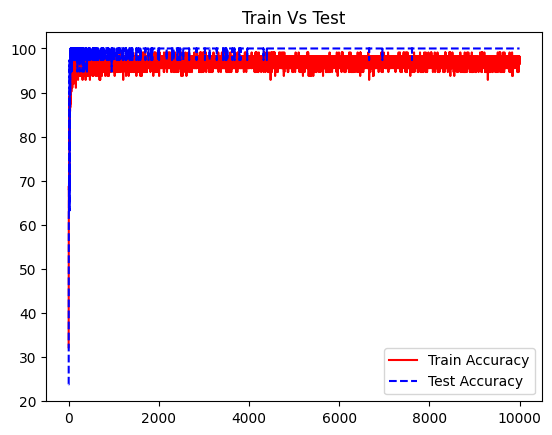

In [ ]:
# Accuracy for the raw-sum version - compare against the averaged run above.
plt.plot(train_acc ,"r", label="Train Accuracy")
plt.plot(test_acc, "b--", label="Test Accuracy")
plt.title("Train Vs Test")

plt.legend();

In [ ]:
# Aside: torch.cat joins along an EXISTING axis, keeping the rank the same
# ((4,)+(4,) -> (8,)).
import torch
x = torch.zeros(4)
y = torch.ones(4)
out = torch.cat([x,y],dim=0 )
out

tensor([0., 0., 0., 0., 1., 1., 1., 1.])

In [ ]:
x

tensor([0., 0., 0., 0.])

In [ ]:
# torch.stack creates a NEW axis instead ((4,)+(4,) -> (4,2) with dim=1).
# cat vs stack is a constant source of shape bugs; the difference is exactly
# whether the rank goes up.
torch.stack([x,y],dim=1)

tensor([[0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.]])